# PVTT 数据采集周报 — 第五周

**项目：** Product Video Template Transfer (PVTT)  
**目标会议：** CVPR 2027  
**负责人：** 王洁怡 (wangjieyi)  
**周期：** 2026-03-16 ~ 2026-03-22  

---

## 任务完成情况

| 子任务 | 状态 | 说明 |
|--------|------|------|
| Shopify爬虫开发 | ✅ 已完成 | `shopify_spider.py` — 支持Shopify独立站批量采集 |
| 多店铺数据采集 | ✅ 已完成 | 4个店铺（gorjana/missoma/goodr/dagnedover），1,477产品 |
| 视频修复下载 | ✅ 已完成 | 修复CDN URL转义bug，补下载73个视频，总计133个 |
| 服务器标准化 | ✅ 已完成 | Amazon 863视频 → 5,258片段（1280×720, 24fps, H.264） |
| 数据上传 | ✅ 已完成 | Shopify数据上传至服务器 |
| 质量报告更新 | ✅ 已完成 | 报告已更新为双平台（Amazon + Shopify）统计 |

---

## 一、本周工作内容

### 1.1 Shopify 独立站爬虫开发

本周新开发了 Shopify 平台爬虫 `shopify_spider.py`，利用 Shopify 公开的 `/products.json` API 采集独立站商品数据。

**核心功能：**
- 自动发现 Shopify 店铺并检测视频可用性 (`--discover`)
- 按类别分类采集产品元数据、图片、视频
- 支持批量爬取多个店铺 (`--batch`)
- Shopify CDN 视频 URL 解析和下载
- 增量爬取，支持断点续爬

### 1.2 多店铺采集结果

调研并尝试了 13 个 Shopify 独立站，最终 4 个成功采集：

| 店铺 | 类别 | 产品数 | 图片 | 视频 | 说明 |
|------|------|--------|------|------|------|
| gorjana.com | 珠宝 | 587 | 3,252 | 27 | 金饰品牌，视频为产品展示 |
| missoma.com | 珠宝 | 446 | 2,348 | 33 | 英国轻奢珠宝，CDN视频 |
| goodr.com | 太阳镜 | 297 | 1,380 | 0 | 运动太阳镜，仅图片 |
| dagnedover.com | 手袋 | 146 | 819 | 0 | 高端手袋，仅图片 |

**放弃的店铺（9个）：** mejuri, kendrascott, analuisa, vitaly, jaxxon, mvmtwatches, filippoloreti, blenders, beistravel — API不可用/被封/无视频

### 1.3 视频修复

发现 Shopify CDN 视频 URL 存在 JSON 转义问题（`\\/\\/` 而非 `//`），导致初次爬取时 116 个产品的视频未能下载。

| 指标 | 数值 |
|------|------|
| 修复前视频数 | 60 |
| 补下载成功 | +73 |
| 修复后视频数 | 133 |
| 下载失败 | 0 |

### 1.4 服务器标准化处理

Amazon 数据已在服务器完成全部标准化处理：

| 指标 | 数值 |
|------|------|
| 输入视频 | 863 |
| 输出片段 | 5,258 |
| 输出大小 | 3.4 GB |
| 标准规格 | 1280×720, 24fps, H.264 |

处理流程：原始视频 → 镜头检测 (PySceneDetect) → 片段分割 → 分辨率/帧率标准化

---

## 二、数据集总览

### 2.1 双平台数据汇总

| 平台 | 产品数 | 图片数 | 视频数 | 大小 |
|------|--------|--------|--------|------|
| Amazon | 865 | 4,926 | 863 | 5.5 GB |
| Shopify | 1,477 | 7,296 | 133 | 1.4 GB |
| **合计** | **2,342** | **12,222** | **996** | **6.9 GB** |

### 2.2 各类别产品与视频数量对比

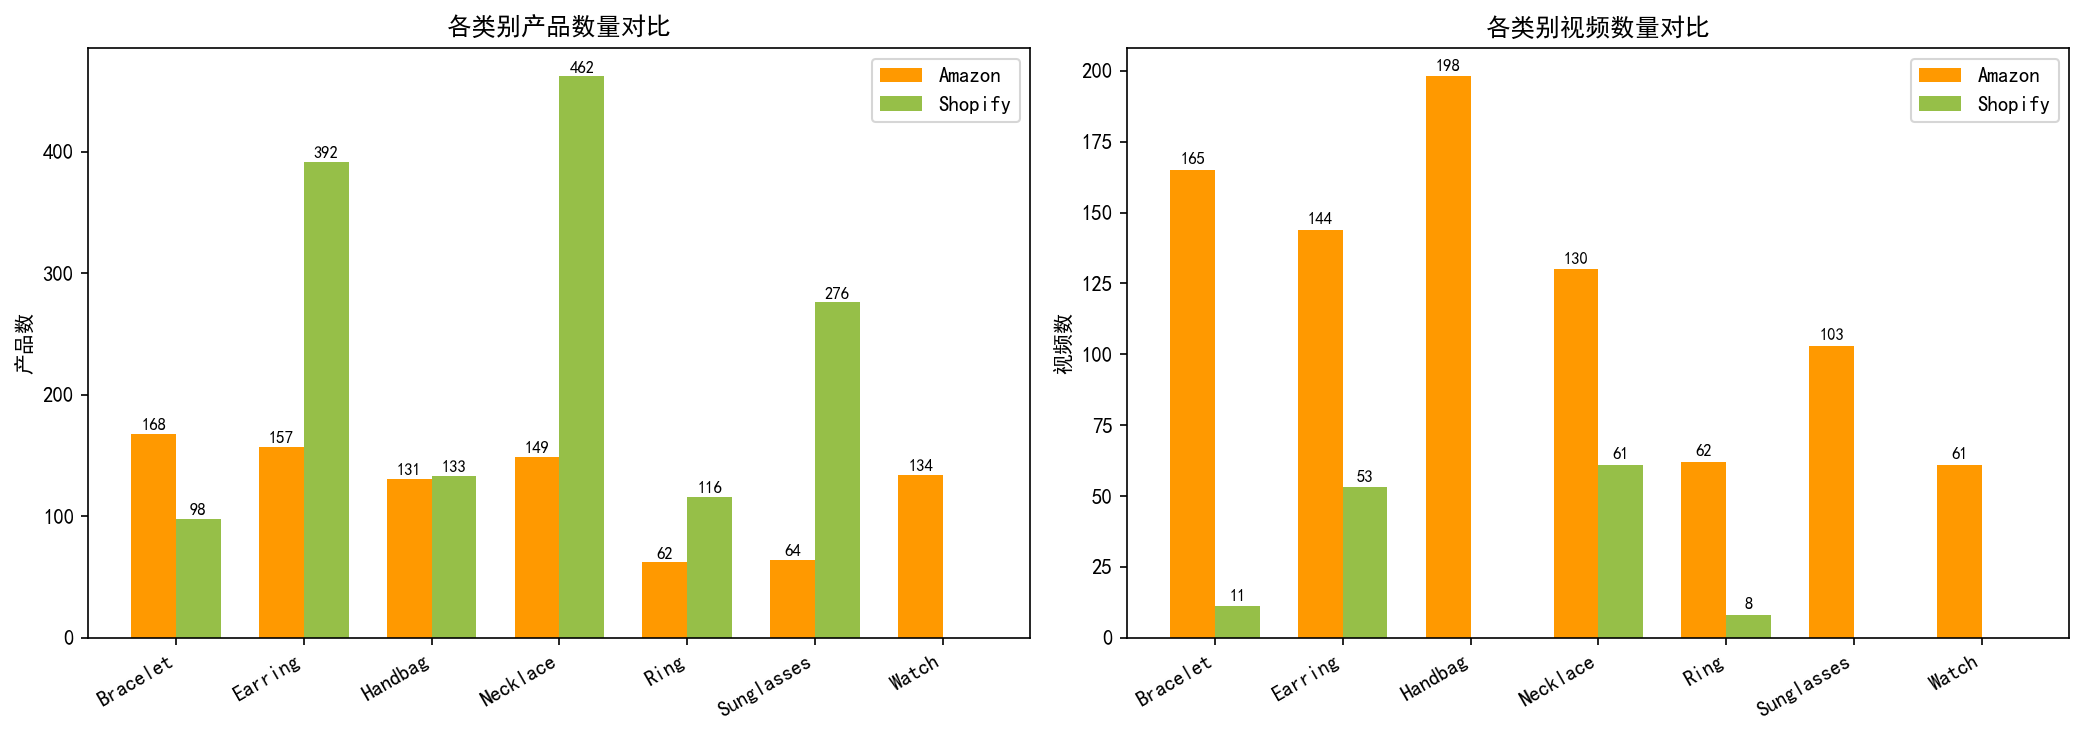

### 2.3 数据来源构成

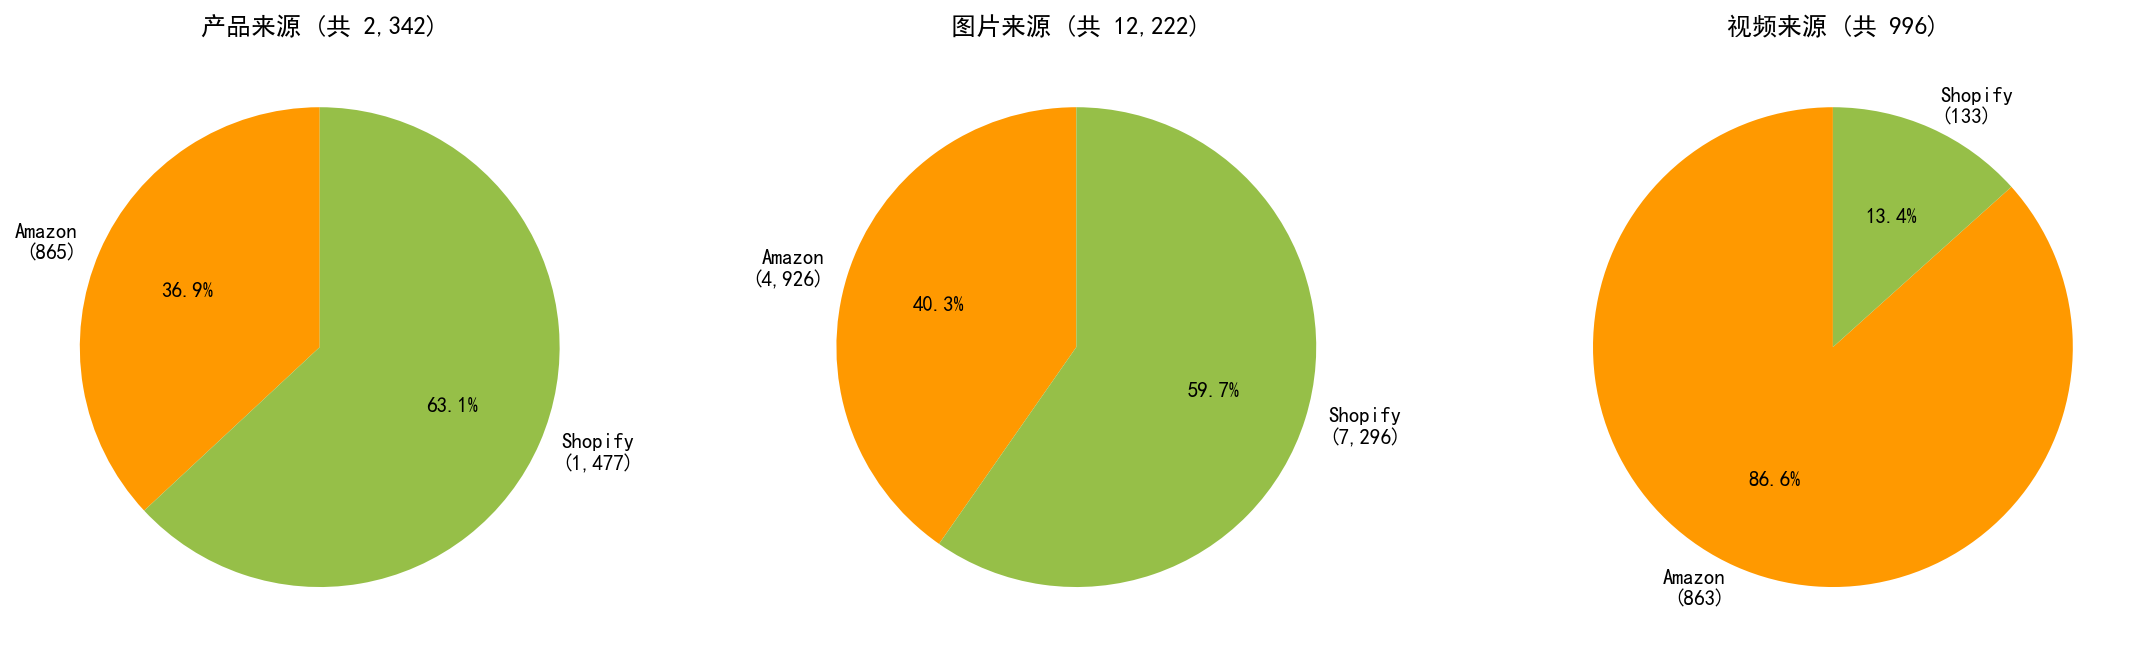

### 2.4 Shopify 各店铺贡献

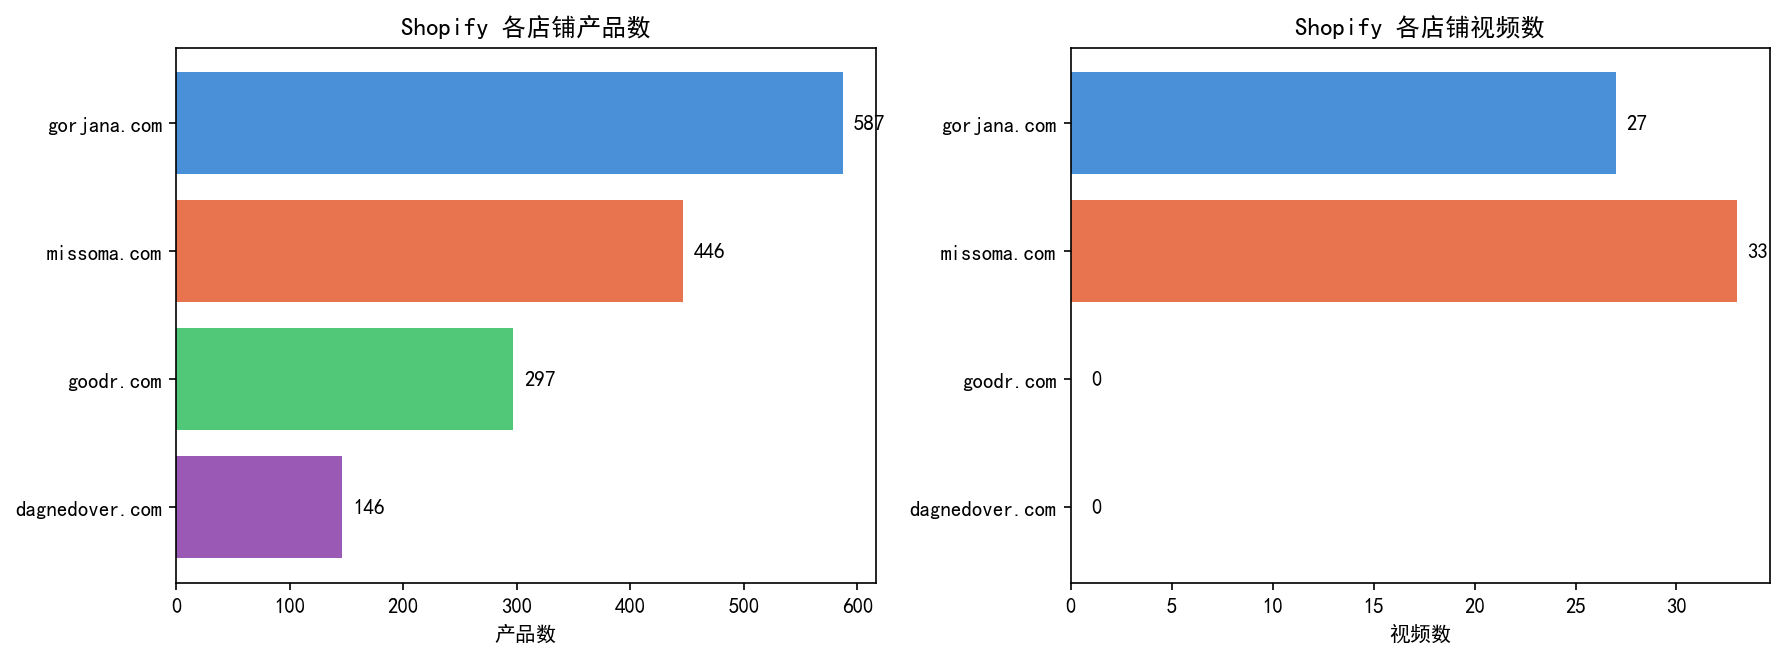

### 2.5 Amazon 各类别明细

| 类别 | 产品数 | 图片数 | 视频数 |
|------|--------|--------|--------|
| Bracelet | 168 | 864 | 165 |
| Earring | 157 | 973 | 144 |
| Handbag | 131 | 739 | 198 |
| Necklace | 149 | 924 | 130 |
| Ring | 62 | 436 | 62 |
| Sunglasses | 64 | 376 | 103 |
| Watch | 134 | 614 | 61 |
| **合计** | **865** | **4,926** | **863** |

### 2.6 Shopify 各类别明细

| 类别 | 产品数 | 图片数 | 视频数 |
|------|--------|--------|--------|
| Bracelet | 98 | 511 | 11 |
| Earring | 392 | 1,903 | 53 |
| Handbag | 133 | 819 | 0 |
| Necklace | 462 | 2,108 | 61 |
| Ring | 116 | 575 | 8 |
| Sunglasses | 276 | 1,380 | 0 |
| **合计** | **1,477** | **7,296** | **133** |

---

## 三、数据增长趋势

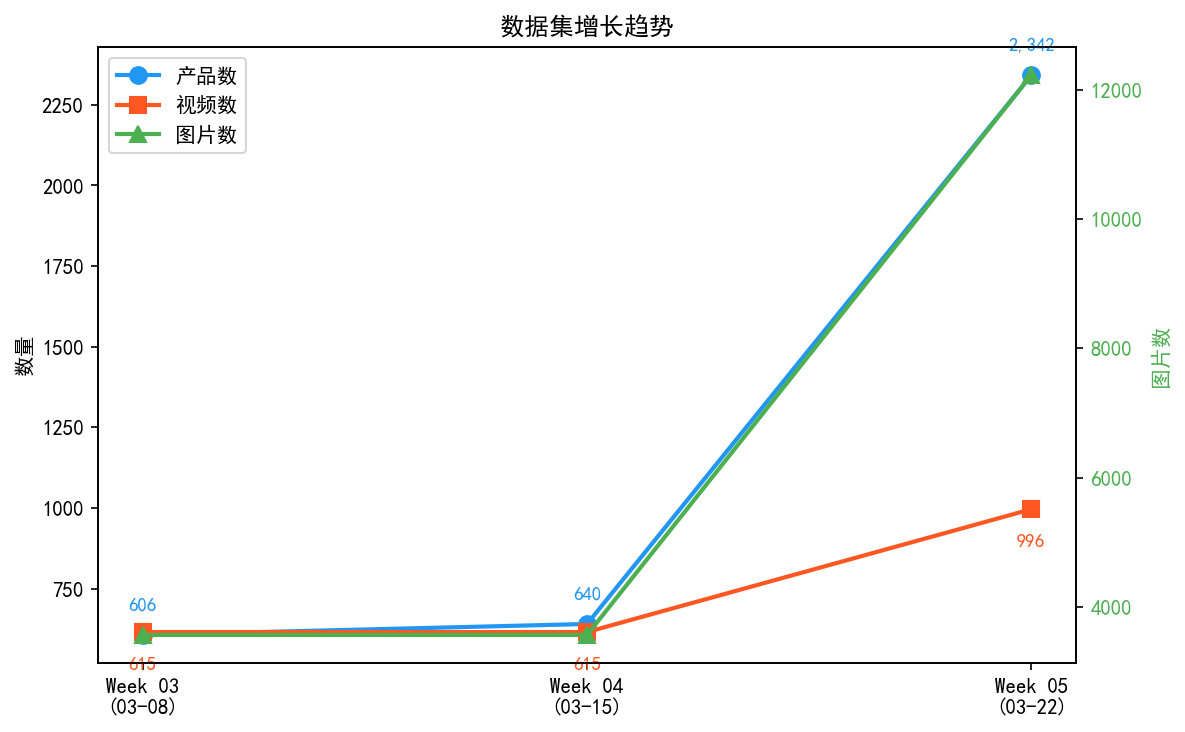

---

## 四、Pipeline 架构

本周新增 Shopify 采集通道，形成双平台并行采集架构：

```
┌─────────────────────────────────────────────────────────────────────┐
│                        PVTT 数据采集 Pipeline                       │
├─────────────────────────────┬───────────────────────────────────────┤
│    Amazon 通道 (主)          │    Shopify 通道 (辅)                   │
│                             │                                       │
│  amazon_spider.py           │  shopify_spider.py                    │
│  ├── 搜索关键词              │  ├── /products.json API               │
│  ├── 产品页解析              │  ├── 产品页视频提取                     │
│  ├── HLS视频下载             │  ├── CDN视频下载                       │
│  └── 元数据保存              │  └── 元数据保存                        │
│                             │                                       │
│  865 产品 | 863 视频         │  1,477 产品 | 133 视频                 │
├─────────────────────────────┴───────────────────────────────────────┤
│                     upload_to_server.py (SFTP)                      │
├─────────────────────────────────────────────────────────────────────┤
│  服务器处理 (RTX 5090 × 8)                                          │
│  PySceneDetect → 标准化 (1280×720, 24fps) → 5,258 clips            │
└─────────────────────────────────────────────────────────────────────┘
```

| 脚本 | 说明 | 运行位置 |
|------|------|----------|
| `amazon_spider.py` | Amazon产品爬虫 | 本地（住宅IP） |
| `shopify_spider.py` | Shopify独立站爬虫 | 本地 |
| `upload_to_server.py` | SFTP增量上传 | 本地 |
| `pvtt_pipeline.py` | 视频标准化处理 | 服务器 |

---

## 五、遇到的问题与解决

| 问题 | 原因 | 解决方案 |
|------|------|----------|
| Shopify视频下载失败 | CDN URL JSON转义 (`\\/\\/`) | `_clean_video_url()` 反转义 + 补下载脚本 |
| 9/13 店铺不可用 | API 403/WAF拦截/无产品 | `--discover` 自动检测 + 手动筛选 |
| C盘空间不足 (33MB) | 缓存和临时文件 | 清理至 2.5GB，数据放D盘 |

---

## 六、下周计划

| 任务 | 优先级 | 说明 |
|------|--------|------|
| Shopify视频服务器标准化 | P0 | 133个Shopify视频 → 镜头检测+标准化处理 |
| 继续扩展数据源 | P1 | 尝试更多Shopify独立站 |
| Amazon数据继续扩展 | P1 | 目标1000+产品，补充watch/ring等薄弱类别 |
| 数据质量分析 | P2 | 视频时长/分辨率分布，识别低质量数据 |

---
*PVTT 数据采集周报 — Week 05 — Product Video Template Transfer (CVPR 2027)*